In [31]:
import matplotlib.pyplot as plt
import numpy as np
H = np.loadtxt('topography_180x360_grid.txt')

In [32]:
R = 6371
n_lat, n_lon = H.shape
dlat = np.pi/n_lat
dlon = 2*np.pi/n_lon
total_area = 0.0
for i in range(n_lat):
    lat = -np.pi/2 + (i+0.5) * dlat
    dA = R**2 * np.cos(lat) * dlat * dlon
    total_area += dA * n_lon

analytical = 4 * np.pi * R**2
print(total_area)

510070945.90578103


In [33]:
R = 6371
n_lat, n_lon = H.shape
dlat = np.pi/n_lat
dlon = 2*np.pi/n_lon
water_area = 0.0
for i in range(n_lat):
    lat = -np.pi/2 + (i+0.5) * dlat
    for j in range(n_lon):
        if (H[i,j]<0):
            dA = R**2 * np.cos(lat) * dlat * dlon
            water_area += dA

proportion_of_earth_covered_by_water = water_area/total_area
print(proportion_of_earth_covered_by_water)

0.7094268678859681


In [34]:
water_volume = 0.0
for i in range(n_lat):
    lat = -np.pi/2 + (i+0.5) * dlat
    for j in range(n_lon):
        if (H[i,j]< 0):
            dA = R**2 * np.cos(lat) * dlat * dlon
            water_volume += dA*1000000*abs(H[i,j])


print(water_volume)

1.3367282835615964e+18


In [35]:
#Part one
xMin = 1.23445
xMax = 2.3445
nn = 17
change = (xMax-xMin)/(nn-1)
x = np.zeros(nn)
for i in range(nn):
    x[i] = xMin + i*change

print(x)

[1.23445    1.30382813 1.37320625 1.44258438 1.5119625  1.58134063
 1.65071875 1.72009688 1.789475   1.85885312 1.92823125 1.99760938
 2.0669875  2.13636562 2.20574375 2.27512187 2.3445    ]


In [36]:
#Part two
#1
water_volume_new = 0.0
for i in range(n_lat):
    lat = -np.pi/2 + (i+0.5) * dlat
    for j in range(n_lon):
        if (H[i,j]< -425):
            dA = R**2 * np.cos(lat) * dlat * dlon
            water_volume_new += dA*1000000*abs(H[i,j])


print(water_volume_new)
print(water_volume_new/water_volume)

1.3330370598789366e+18
0.9972386133157706


In [37]:
#2
R = 6371
n_lat, n_lon = H.shape
dlat = np.pi/n_lat
dlon = 2*np.pi/n_lon
water_area_new = 0.0
for i in range(n_lat):
    lat = -np.pi/2 + (i+0.5) * dlat
    for j in range(n_lon):
        if (H[i,j]<625):
            dA = R**2 * np.cos(lat) * dlat * dlon
            water_area_new += dA

print(water_area_new)
print(water_area_new/total_area)

453224581.4342241
0.8885520437346035


In [38]:
#3
water_volume*1.055
print(water_volume*1.055)
water_volume_new_2 = 0.0
for i in range(n_lat):
    lat = -np.pi/2 + (i+0.5) * dlat
    for j in range(n_lon):
        if (H[i,j]< 2172):
            dA = R**2 * np.cos(lat) * dlat * dlon
            water_volume_new_2 += dA*1000000*abs(H[i,j])

print(water_volume_new_2)

1.410248339157484e+18
1.4102517773672497e+18


In [39]:
#Part 3
lat_min = 33;
lat_max = 42;
lon_min = -125;
lon_max = -115;

In [40]:
CAC = np.loadtxt('CA_coast_line_no_islands.txt', usecols=(0,1)) 
CAB = np.loadtxt('CA_boundary2.txt', usecols=(0,1)) 
print(CAC.shape,CAB.shape)

(1282, 2) (1295, 2)


In [41]:
CAC1 = np.append( CAC,  [[lon_min,max(CAC[:,1])]],axis=0)
CAC2 = np.append( CAC1, [[lon_min,min(CAC[:,1])]],axis=0)
ocean = CAC2.copy()

In [42]:
plate = np.loadtxt('plate.txt', usecols=(0,1)) 
print(plate.shape)

(925, 2)


In [43]:
#lat_UCB = 37+52/60+19.54/3600;
#lat_LAX = 33+56/60+38.89/3600;
lat_LAX = 33.9416
lon_LAX = -118.4085
lat_UCB = 37.8716
lon_UCB = -122.2727

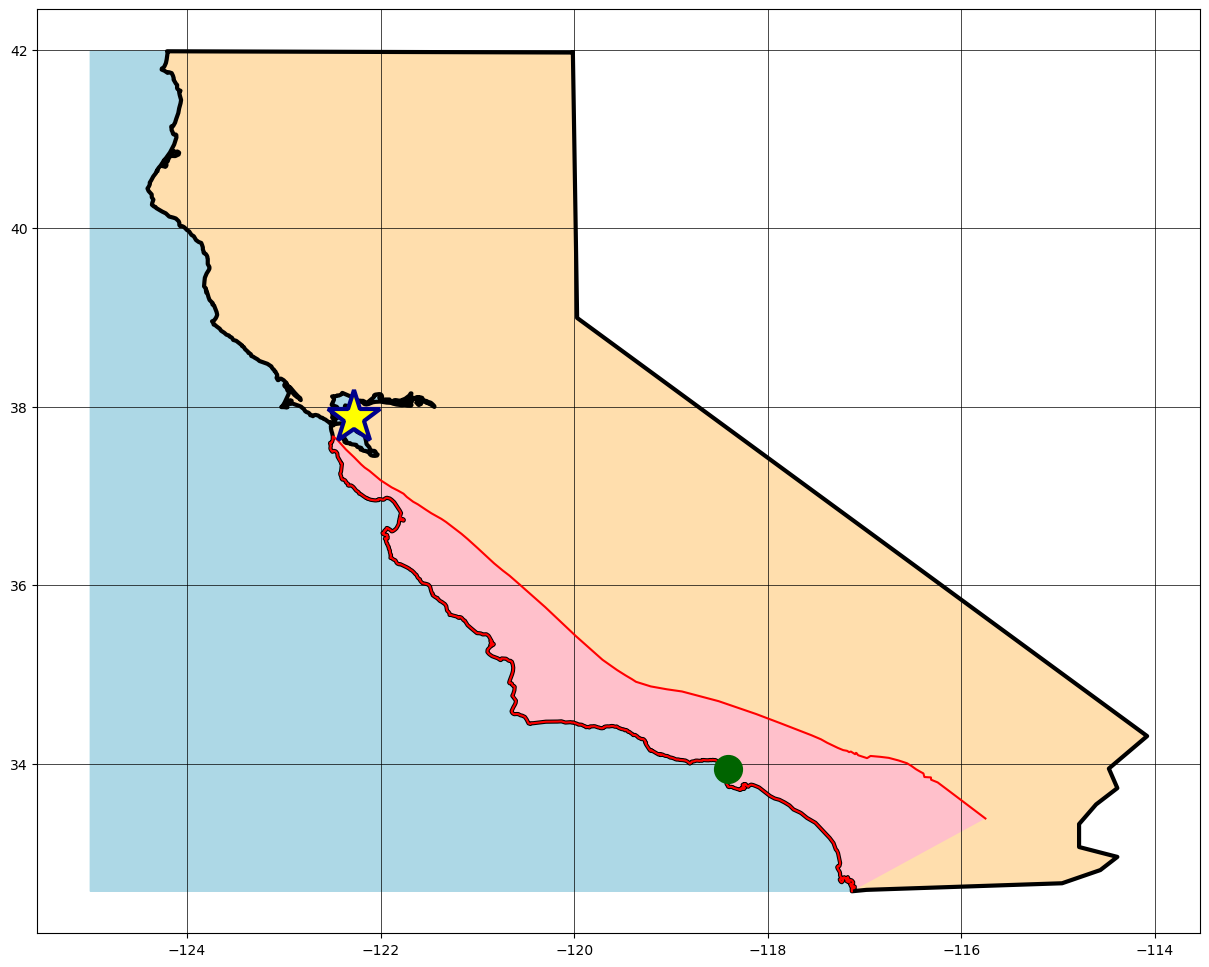

In [44]:
plt.rcParams['figure.figsize'] = [15, 12]

plt.plot(CAB[:,0],CAB[:,1],'k-',lw=3)
plt.fill(CAB[:,0],CAB[:,1],'navajowhite')

#plt.fill(land[:,0],land[:,1],'-',color='lightgrey')
plt.fill(ocean[:,0],ocean[:,1],'-',color='lightblue')

plt.plot(plate[:,0],plate[:,1],'r-')
plt.fill(plate[:,0],plate[:,1],'pink')

plt.plot(lon_LAX,lat_LAX,'o',color='darkgreen',ms=20)
plt.plot(lon_UCB,lat_UCB,'*',mec='darkblue',mew=3,mfc='yellow',ms=40)

plt.grid(color='k', linestyle='-', linewidth=0.5)
plt.show()

In [70]:
#a)
lat_degree = 2*np.pi*R/360
lon_degree = np.pi*R*np.cos(np.radians(35.5))/180
time_points = [1,5,25]
years = []
for i in time_points:
    years.append(i*1000000)

In [77]:
rate = 35/1000000 #this is the rate that the plate moves in km/year in stead of mm/year
displacements = []
for i in years:
    displacements.append(rate*i)

angle = 180 - 32
angle_radians = np.radians(angle)

In [78]:
lon_change = []
for i in displacements:
    x = i*np.cos(angle_radians)*(1/lon_degree)
    lon_change.append(x)

lat_change = []
for i in displacements:
    y = i*np.sin(angle_radians)*(1/lat_degree)
    lat_change.append(y)

In [79]:
new_plate_1 = plate.copy()
new_plate_2 = plate.copy()
new_plate_3 = plate.copy()

new_plate_1[:,0] += lon_change[0]
new_plate_1[:,1] += lat_change[0]
new_plate_2[:,0] += lon_change[1]
new_plate_2[:,1] += lat_change[1]
new_plate_3[:,0] += lon_change[2]
new_plate_3[:,1] += lat_change[2]

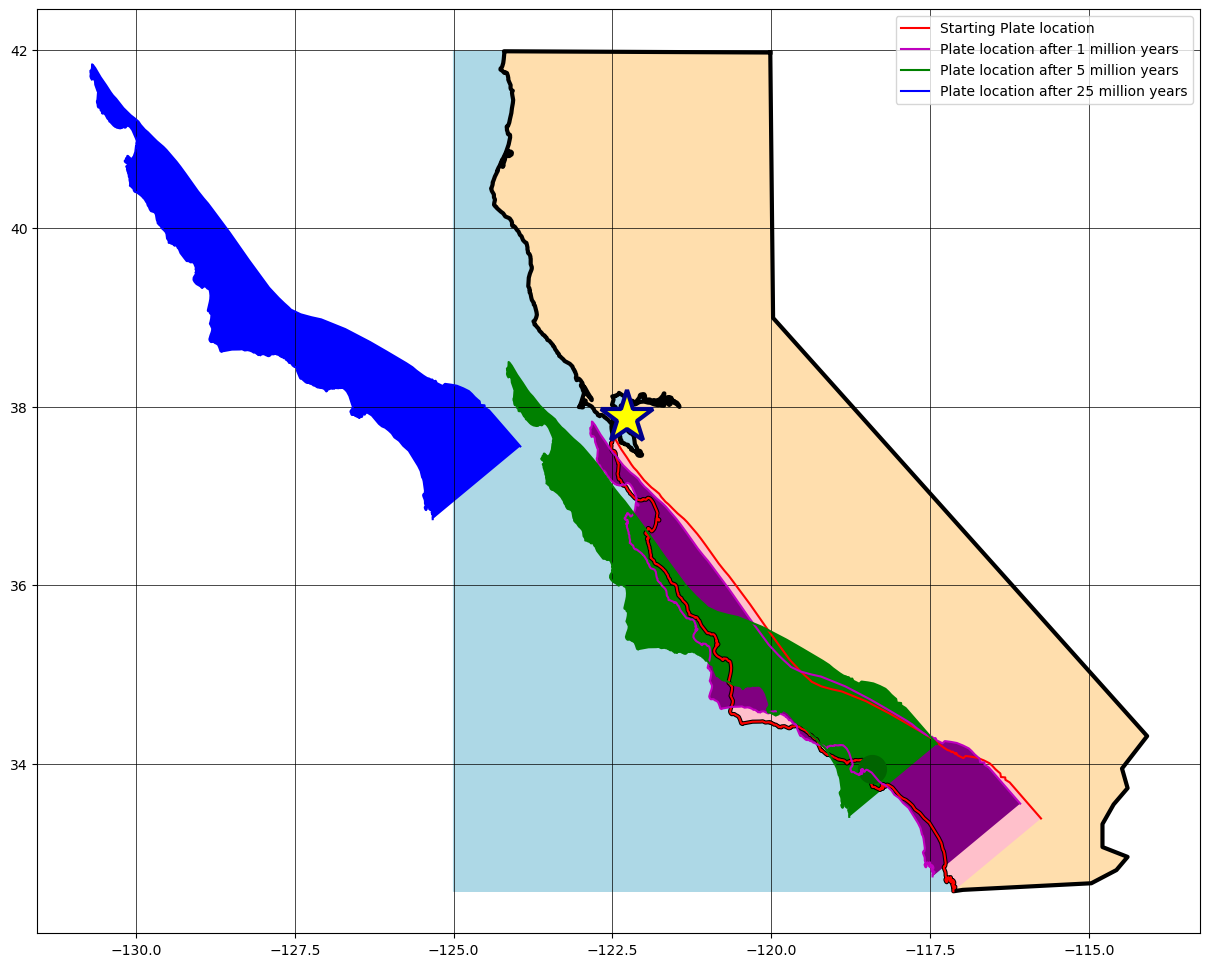

In [84]:
plt.rcParams['figure.figsize'] = [15, 12]

plt.plot(CAB[:,0],CAB[:,1],'k-',lw=3)
plt.fill(CAB[:,0],CAB[:,1],'navajowhite')

#plt.fill(land[:,0],land[:,1],'-',color='lightgrey')
plt.fill(ocean[:,0],ocean[:,1],'-',color='lightblue')

plt.plot(plate[:,0],plate[:,1],'r-', label = "Starting Plate location")
plt.fill(plate[:,0],plate[:,1],'pink')

plt.plot(lon_LAX,lat_LAX,'o',color='darkgreen',ms=20)
plt.plot(lon_UCB,lat_UCB,'*',mec='darkblue',mew=3,mfc='yellow',ms=40)

plt.grid(color='k', linestyle='-', linewidth=0.5)

#these are the updated plate plots
plt.plot(new_plate_1[:,0],new_plate_1[:,1], 'm-', label = "Plate location after 1 million years")
plt.fill(new_plate_1[:,0], new_plate_1[:,1], 'purple')
plt.plot(new_plate_2[:,0], new_plate_2[:,1], 'g-', label = "Plate location after 5 million years")
plt.fill(new_plate_2[:,0], new_plate_2[:,1], 'green')
plt.plot(new_plate_3[:,0], new_plate_3[:,1], 'b-', label = "Plate location after 25 million years")
plt.fill(new_plate_3[:,0], new_plate_3[:,1], 'blue')
plt.legend()
plt.show()

In [86]:
#b)
lat_difference = lat_UCB - lat_LAX
lat_difference

3.9299999999999997

In [88]:
lat_difference_distance = lat_difference*lat_degree
lat_difference_distance

436.9960617131158

In [91]:
north_movement_rate = (np.sin(np.radians(32))*35)/1000000
north_movement_rate

np.float64(1.854717424816217e-05)

In [93]:
time_years = lat_difference_distance/north_movement_rate
time_years

np.float64(23561328.31158458)